### 1. Path Configuration & Import

In [ ]:
# 1. Standard Python utility libraries
import os
import sys

# 2. Heavy-lifting data analysis packages
import xarray as xr
import pandas as pd
import numpy as np

# 3. Data visualization engine
import matplotlib.pyplot as plt

# 4. Inline notebook visualization settings
%matplotlib inline

print("All processing and plotting libraries loaded successfully!")

# Force Jupyter to automatically reload external modules when they change
%load_ext autoreload
%autoreload 2

# Append parent directory to the path
parent_dir = os.path.abspath(os.path.join('..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

folders = [
    "/Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/SantaRosa",
    "/Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/PaloVerde"
]

for folder in folders:
    if os.path.exists(folder):
        for file in os.listdir(folder):
            # Delete both old .nc files and the misnamed binary .csv placeholders
            if file.endswith('.nc') or file.endswith('.csv'):
                os.remove(os.path.join(folder, file))
                print(f"Removed old file: {file}")

All processing and plotting libraries loaded successfully!
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Removed old file: era5_timeseries_1995_2025.nc
Removed old file: era5_timeseries_1995_2025.csv
Removed old file: era5_timeseries_1995_2025.nc
Removed old file: era5_timeseries_1995_2025.csv


### 2. Set up download dir and execute request of ERA5 data

In [10]:
import os
import cdsapi

# Define site coordinates and target directories
sites_config = {
    "SantaRosa": {
        "lat": 10.58, 
        "lon": -85.45, 
        "folder": "/Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/SantaRosa"
    },
    "PaloVerde": {
        "lat": 10.35,  # Snapped closest grid point is 10.25, -85.25
        "lon": -85.35, 
        "folder": "/Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/PaloVerde"
    }
}

variables = ["2m_temperature", "2m_dewpoint_temperature", "total_precipitation"]
client = cdsapi.Client()

for site_name, config in sites_config.items():
    os.makedirs(config["folder"], exist_ok=True)
    
    # Snap coordinates to the closest 0.25-degree grid cell
    snapped_lat = round(config["lat"] * 4) / 4
    snapped_lon = round(config["lon"] * 4) / 4
    
    output_zip_path = os.path.join(config["folder"], "era5_timeseries_1995_2025.zip")
    
    if os.path.exists(output_zip_path):
        print(f"Archive for {site_name} already exists. Skipping download.")
        continue
        
    print(f"\nRequesting data for {site_name} (Snapped to Lat {snapped_lat}, Lon {snapped_lon})...")
    
    request = {
        "variable": variables,
        "location": {
            "longitude": snapped_lon, 
            "latitude": snapped_lat
        },
        "date": ["1995-01-01/2025-12-31"],
        "data_format": "csv"
    }
    
    # Force the API to save directly into the destination folder path
    client.retrieve("reanalysis-era5-single-levels-timeseries", request).download(output_zip_path)
    print(f"--> Saved to: {output_zip_path}")


Requesting data for SantaRosa (Snapped to Lat 10.5, Lon -85.5)...


2026-06-09 17:05:18,064 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
2026-06-09 17:05:18,065 INFO Request ID is dfe36f2d-58b6-4045-b448-6bd8ad9e452f
2026-06-09 17:05:18,592 INF

--> Saved to: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/SantaRosa/era5_timeseries_1995_2025.zip

Requesting data for PaloVerde (Snapped to Lat 10.25, Lon -85.25)...


2026-06-09 17:05:45,952 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
2026-06-09 17:05:45,953 INFO Request ID is fce83535-853a-4744-b13b-5b5340ed8688
2026-06-09 17:05:47,755 INF

--> Saved to: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/PaloVerde/era5_timeseries_1995_2025.zip


### 4. Process files


Processing Site: SantaRosa
Opening Archive: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/SantaRosa/era5_timeseries_1995_2025.zip
Exporting hourly metrics to: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/SantaRosa_hourly_era5.csv...
Aggregating to daily summaries...
Saved daily summary to: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/SantaRosa/SantaRosa_daily_summary_1995_2025.csv
Generating diagnostic dashboard for SantaRosa...


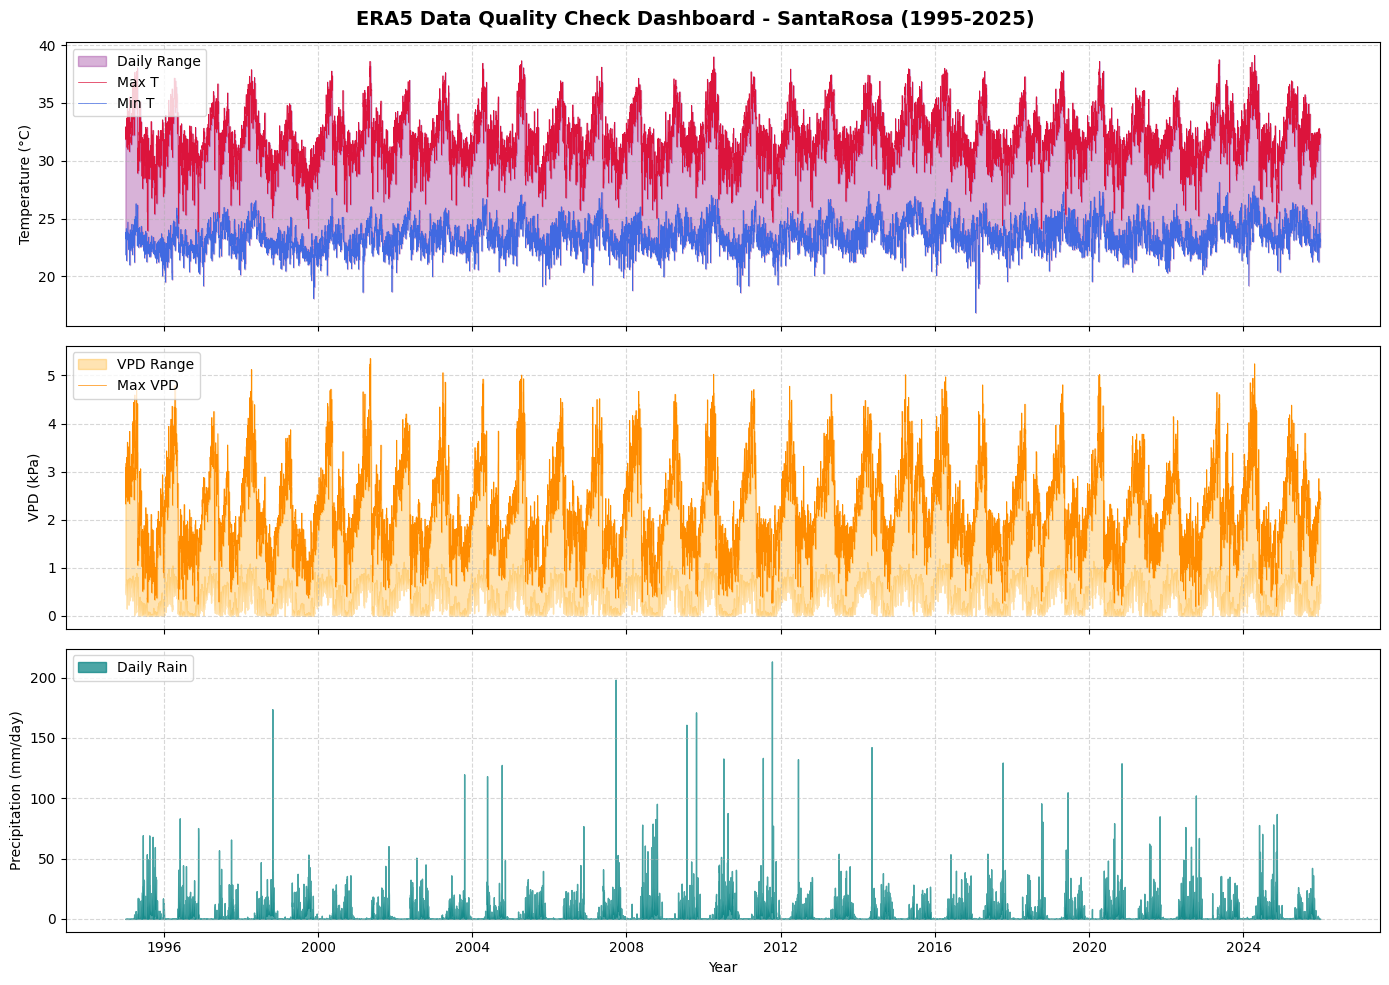


Processing Site: PaloVerde
Opening Archive: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/PaloVerde/era5_timeseries_1995_2025.zip
Exporting hourly metrics to: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/PaloVerde_hourly_era5.csv...
Aggregating to daily summaries...
Saved daily summary to: /Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/PaloVerde/PaloVerde_daily_summary_1995_2025.csv
Generating diagnostic dashboard for PaloVerde...


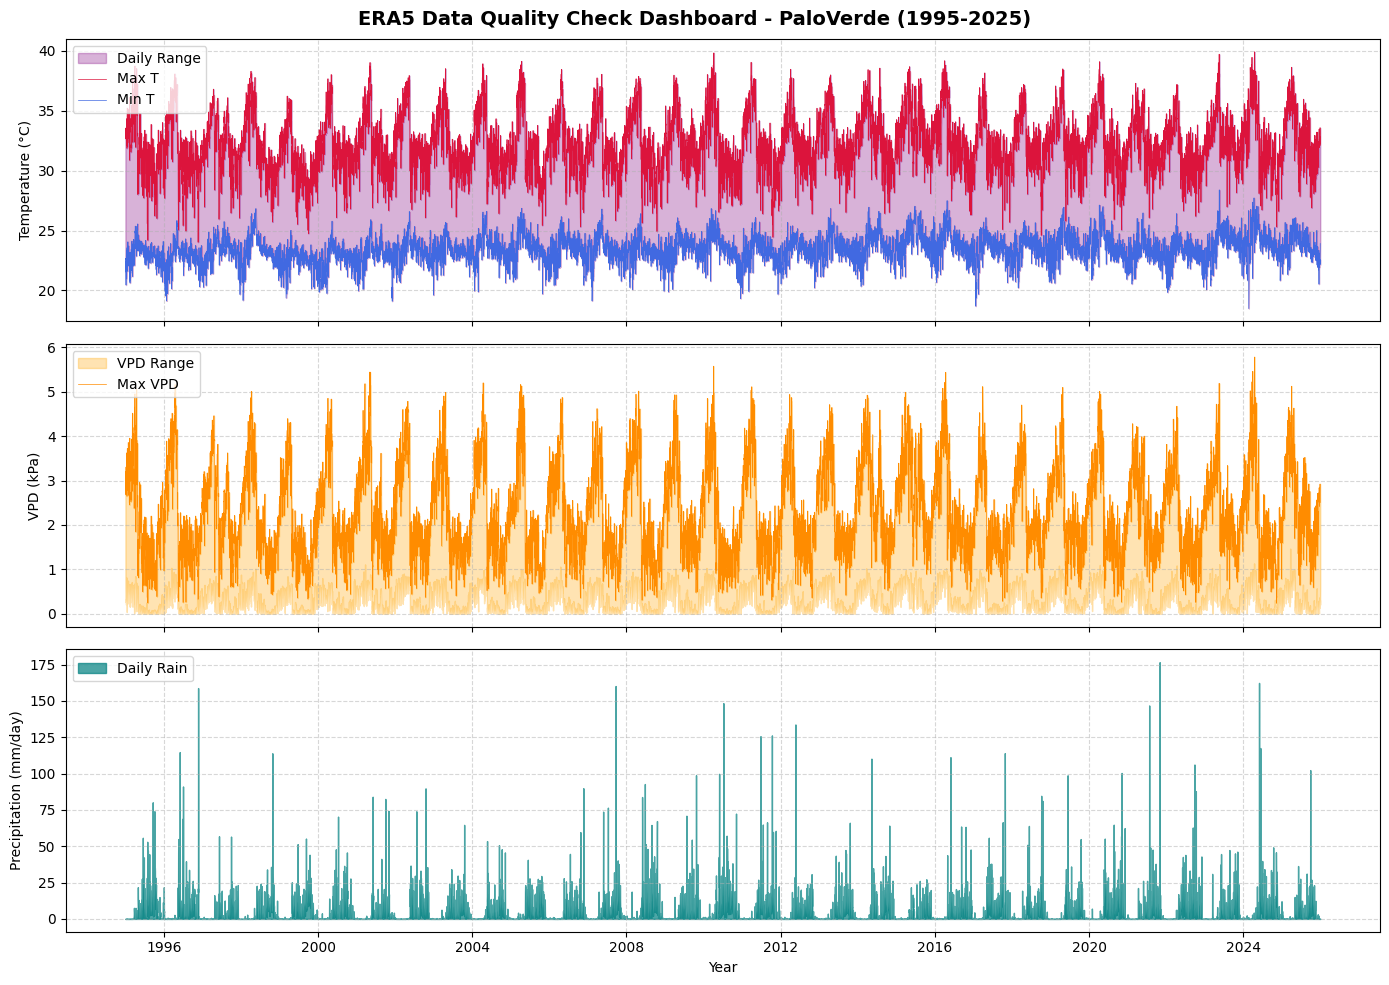


Processing complete! All files parsed and visually verified.


In [11]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define your exact directory paths
sites = {
    "SantaRosa": "/Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/SantaRosa",
    "PaloVerde": "/Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis/PaloVerde"
}

master_export_dir = "/Users/ger/Library/CloudStorage/Dropbox/annual_census_CR/climate_data/ERA5Reanalysis"
os.makedirs(master_export_dir, exist_ok=True)

for site_name, site_folder in sites.items():
    # TARGET THE ZIP FILE SPECIFICALLY
    zip_files = [f for f in os.listdir(site_folder) if f.endswith('.zip')]
    
    if not zip_files:
        print(f"Warning: No .zip archive found in {site_folder}. Skipping...")
        continue
        
    file_path = os.path.join(site_folder, zip_files[0])
    print(f"\n=======================================================")
    print(f"Processing Site: {site_name}")
    print(f"Opening Archive: {file_path}")
    print(f"=======================================================")
    
    # Extract the internal data frame straight out of the compressed zip
    with zipfile.ZipFile(file_path, 'r') as z:
        # Find the actual data table inside the zip file list, ignoring Mac metadata files
        data_filename = [f for f in z.namelist() if f.endswith('.csv') and not f.startswith('.')][0]
        with z.open(data_filename) as f:
            df_raw = pd.read_csv(f)
            
    df_raw.columns = [col.lower().strip() for col in df_raw.columns]
    
    # 1. Unstack from long format to column format if needed
    if 'variable' in df_raw.columns and 'value' in df_raw.columns:
        time_col = 'valid_time' if 'valid_time' in df_raw.columns else 'time'
        df_hourly = df_raw.pivot(index=time_col, columns='variable', values='value').reset_index()
    else:
        df_hourly = df_raw.copy()
        
    time_col = 'valid_time' if 'valid_time' in df_hourly.columns else 'time'
    df_hourly[time_col] = pd.to_datetime(df_hourly[time_col])
    df_hourly = df_hourly.sort_values(by=time_col).set_index(time_col)
    
    # 2. Map standard variable names dynamically
    t2m_col = [c for c in df_hourly.columns if 'temp' in c and 'dew' not in c or c == 't2m'][0]
    d2m_col = [c for c in df_hourly.columns if 'dew' in c or c == 'd2m'][0]
    tp_col = [c for c in df_hourly.columns if 'precip' in c or c == 'tp'][0]
    
    # 3. Standardize Temperature and compute VPD via Tetens Equation
    if df_hourly[t2m_col].mean() > 150:  # If data is in Kelvin
        temp_c = df_hourly[t2m_col] - 273.15
        dew_c = df_hourly[d2m_col] - 273.15
    else:
        temp_c = df_hourly[t2m_col]
        dew_c = df_hourly[d2m_col]
        
    es = 0.61078 * np.exp((17.27 * temp_c) / (temp_c + 237.3))
    ea = 0.61078 * np.exp((17.27 * dew_c) / (dew_c + 237.3))
    vpd = np.where((es - ea) >= 0, es - ea, 0)
    
    # Standardize Precipitation units to mm
    rain_mm = df_hourly[tp_col] * 1000 if df_hourly[tp_col].max() < 0.5 else df_hourly[tp_col]
    
    # 4. Save clean master hourly CSVs to the main ERA5Reanalysis directory
    df_hourly_clean = pd.DataFrame(index=df_hourly.index)
    df_hourly_clean['temperature_C'] = temp_c
    df_hourly_clean['dewpoint_C'] = dew_c
    df_hourly_clean['vpd_kPa'] = vpd
    df_hourly_clean['precipitation_mm'] = rain_mm
    df_hourly_clean = df_hourly_clean.reset_index()
    
    hourly_output_path = os.path.join(master_export_dir, f"{site_name}_hourly_era5.csv")
    print(f"Exporting hourly metrics to: {hourly_output_path}...")
    df_hourly_clean.to_csv(hourly_output_path, index=False)
    
    # 5. Create Daily summaries
    print("Aggregating to daily summaries...")
    df_hourly_clean = df_hourly_clean.set_index(time_col)
    daily_summary = df_hourly_clean.resample('1D').agg({
        'temperature_C': ['min', 'max'],
        'vpd_kPa': ['min', 'max'],
        'precipitation_mm': 'sum'
    })
    daily_summary.columns = ['t_min_C', 't_max_C', 'vpd_min_kPa', 'vpd_max_kPa', 'rain_total_mm']
    daily_summary = daily_summary.reset_index()
    
    daily_output_path = os.path.join(site_folder, f"{site_name}_daily_summary_1995_2025.csv")
    daily_summary.to_csv(daily_output_path, index=False)
    print(f"Saved daily summary to: {daily_output_path}")

    # 6. Quality Check Plots
    print(f"Generating diagnostic dashboard for {site_name}...")
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"ERA5 Data Quality Check Dashboard - {site_name} (1995-2025)", fontsize=14, fontweight='bold')
    
    axes[0].fill_between(daily_summary[time_col], daily_summary['t_min_C'], daily_summary['t_max_C'], color='purple', alpha=0.3, label='Daily Range')
    axes[0].plot(daily_summary[time_col], daily_summary['t_max_C'], color='crimson', linewidth=0.5, label='Max T')
    axes[0].plot(daily_summary[time_col], daily_summary['t_min_C'], color='royalblue', linewidth=0.5, label='Min T')
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='upper left')
    
    axes[1].fill_between(daily_summary[time_col], daily_summary['vpd_min_kPa'], daily_summary['vpd_max_kPa'], color='orange', alpha=0.3, label='VPD Range')
    axes[1].plot(daily_summary[time_col], daily_summary['vpd_max_kPa'], color='darkorange', linewidth=0.5, label='Max VPD')
    axes[1].set_ylabel("VPD (kPa)")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend(loc='upper left')
    
    axes[2].fill_between(daily_summary[time_col], daily_summary['rain_total_mm'], color='teal', alpha=0.7, label='Daily Rain')
    axes[2].set_ylabel("Precipitation (mm/day)")
    axes[2].set_xlabel("Year")
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig(os.path.join(site_folder, f"{site_name}_diagnostic_check.png"), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("\nProcessing complete! All files parsed and visually verified.")

